In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import confusion_matrix, accuracy_score
import ipywidgets as widgets
from IPython.display import display

In [2]:


data = pd.read_excel(r"C:\Study content\ML\DATASETS\Online-Retail.xlsx")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
data.dropna(inplace=True)

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

data = data[data['Quantity'] > 0]
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
reference_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [5]:
X=rfm[['Recency', 'Frequency']]
y = np.where(rfm['Monetary'] > rfm['Monetary'].median(), 1, 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3471, 2), (868, 2), (3471,), (868,))

In [6]:
model = CatBoostClassifier(iterations=200, learning_rate=0.01, depth=5, verbose=False)

model.fit(X_train, y_train)
acc = accuracy_score(y_test, model.predict(X_test))
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.8468


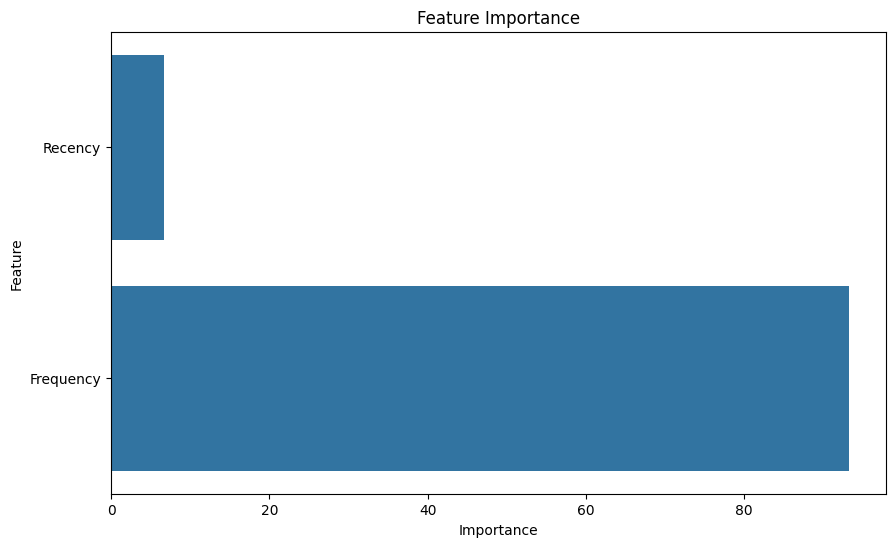

In [7]:
feature_importance = model.get_feature_importance()
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.show()

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'iterations': [200, 400, 600],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [3, 5, 10]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Accuracy:")
print(grid_search.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters:
{'depth': 8, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.03}

Best CV Accuracy:
0.8274252068086165


In [10]:
import ipywidgets as widgets
from IPython.display import display

# --------------------------------------------------
# Prepare product list
# --------------------------------------------------

# Get unique products
products = data['Description'].dropna().unique().tolist()

# Sort products alphabetically
products = sorted(products)

# --------------------------------------------------
# Create widgets
# --------------------------------------------------

recency_input = widgets.IntSlider(
    min=0,
    max=365,
    step=1,
    value=30,
    description='Recency:',
    continuous_update=False
)

frequency_input = widgets.IntSlider(
    min=1,
    max=100,
    step=1,
    value=5,
    description='Frequency:',
    continuous_update=False
)

# Product slider
product_input = widgets.IntSlider(
    min=0,
    max=len(products) - 1,
    step=1,
    value=0,
    description='Product:',
    continuous_update=False
)

# Label showing currently selected product
product_label = widgets.Label(
    value=f"Selected Product: {products[0]}"
)

output = widgets.Output()


# --------------------------------------------------
# Prediction function
# --------------------------------------------------

def make_prediction(recency, frequency):

    # IMPORTANT:
    # Model was trained only on Recency and Frequency
    input_data = pd.DataFrame({
        'Recency': [recency],
        'Frequency': [frequency]
    })

    prediction = model.predict(input_data)[0]

    if prediction == 1:
        return "Recommend"
    else:
        return "Do not recommend"


# --------------------------------------------------
# Update prediction
# --------------------------------------------------

def update_prediction(change=None):

    selected_product = products[product_input.value]

    # Update product name
    product_label.value = f"Selected Product: {selected_product}"

    with output:
        output.clear_output()

        prediction = make_prediction(
            recency_input.value,
            frequency_input.value
        )

        print(f"Product: {selected_product}")
        print(f"Recency: {recency_input.value}")
        print(f"Frequency: {frequency_input.value}")
        print(f"Recommendation: {prediction}")


# --------------------------------------------------
# Connect widgets
# --------------------------------------------------

recency_input.observe(update_prediction, names='value')
frequency_input.observe(update_prediction, names='value')
product_input.observe(update_prediction, names='value')


# --------------------------------------------------
# Display widget
# --------------------------------------------------

display(
    recency_input,
    frequency_input,
    product_input,
    product_label,
    output
)


update_prediction()

IntSlider(value=30, continuous_update=False, description='Recency:', max=365)

IntSlider(value=5, continuous_update=False, description='Frequency:', min=1)

IntSlider(value=0, continuous_update=False, description='Product:', max=3876)

Label(value='Selected Product:  4 PURPLE FLOCK DINNER CANDLES')

Output()